In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

daily_df = pd.read_csv('day.csv')



daily_df['dteday'] = pd.to_datetime(daily_df['dteday'])
daily_df = daily_df.sort_values('dteday').reset_index(drop=True)

In [28]:
daily_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


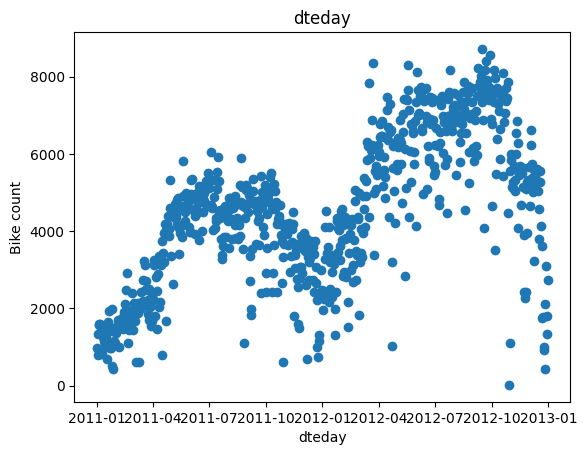

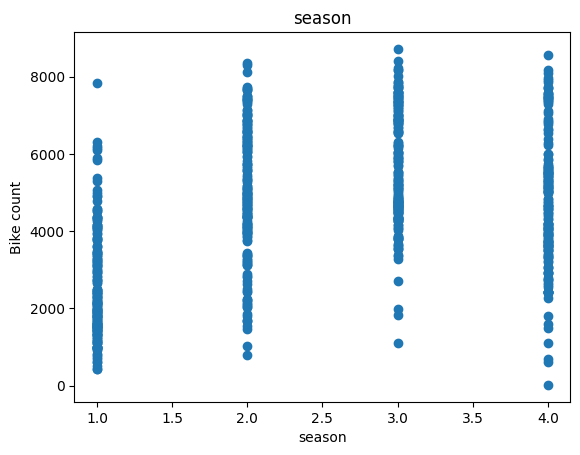

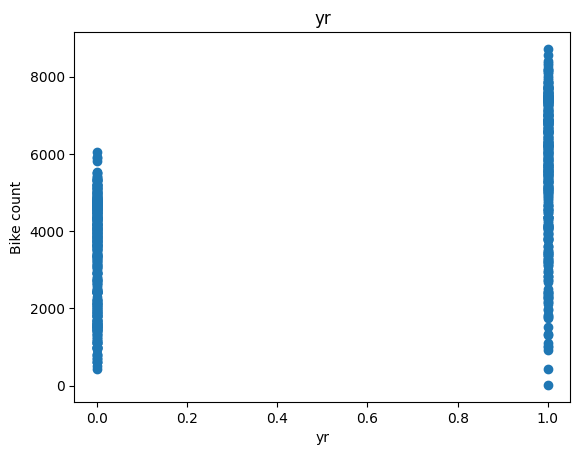

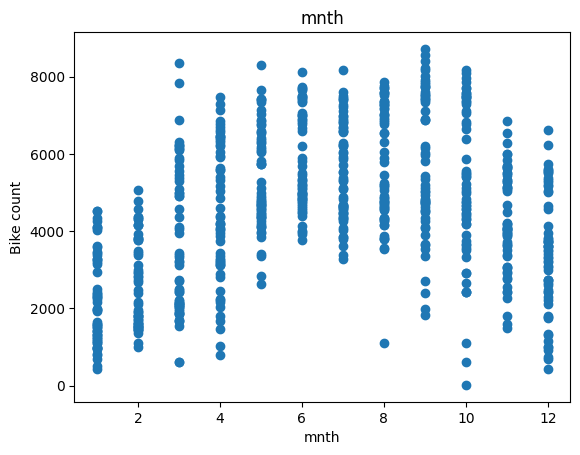

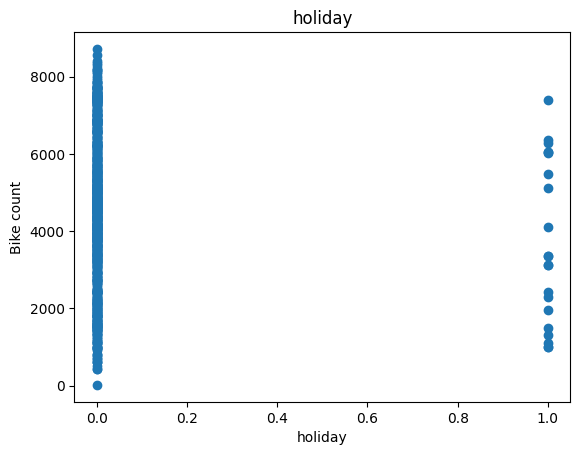

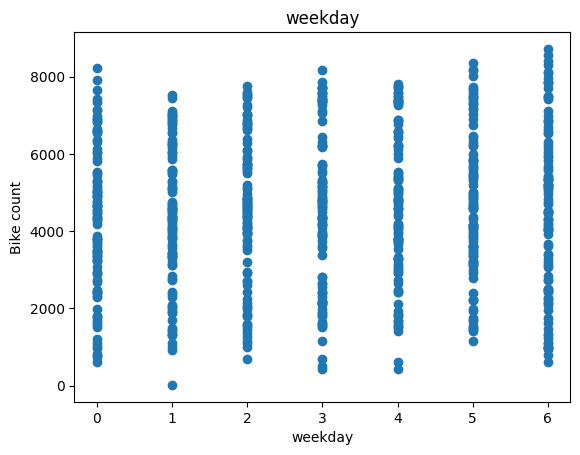

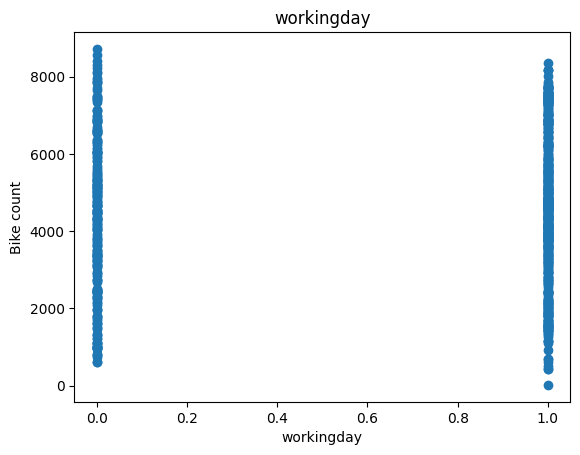

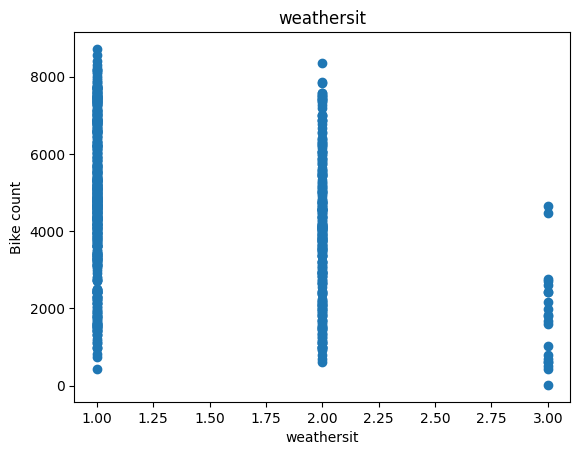

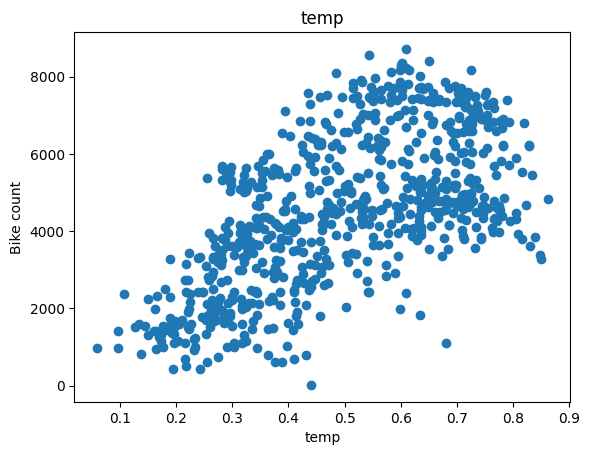

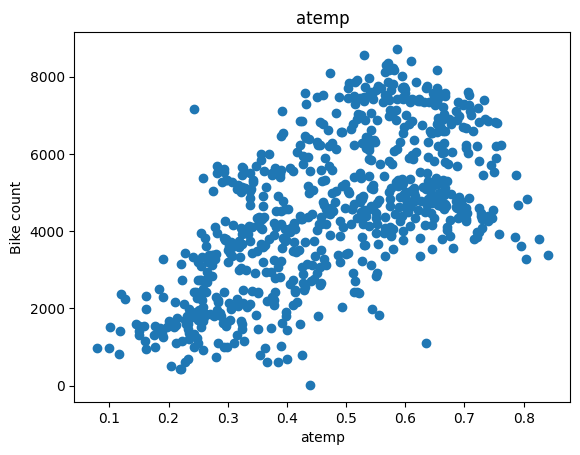

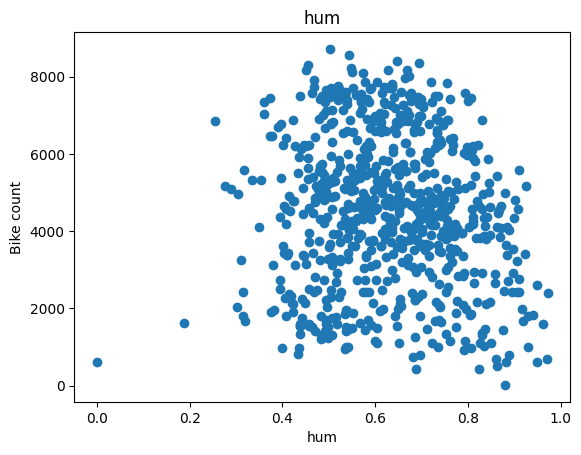

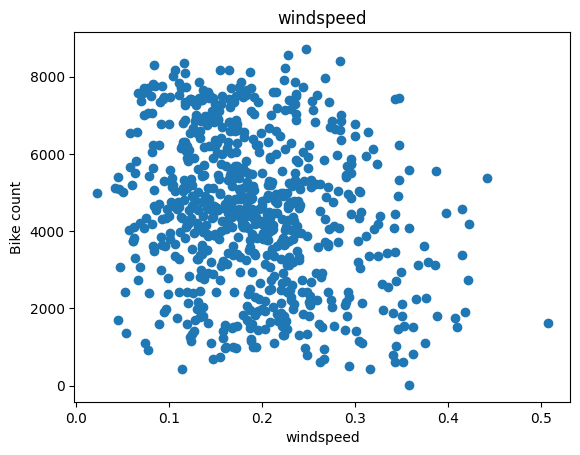

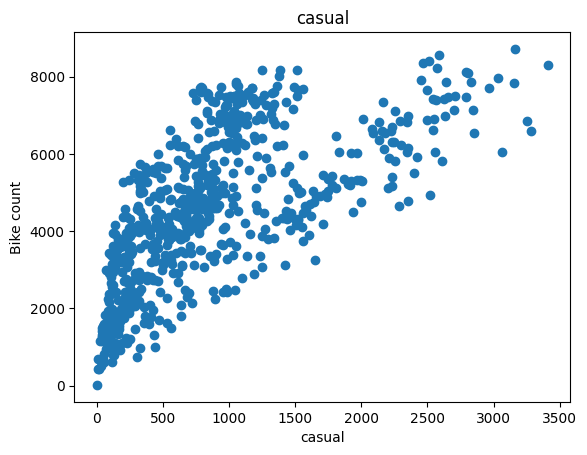

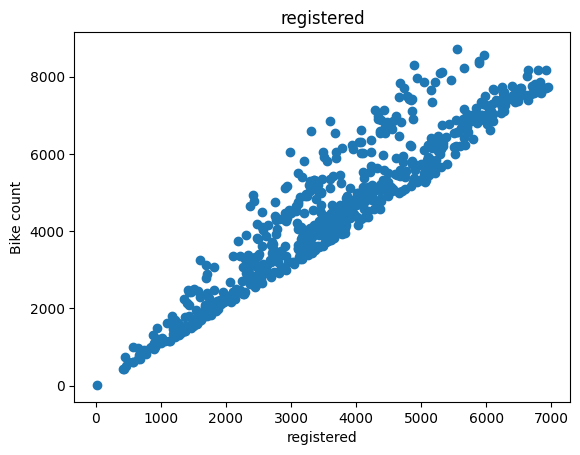

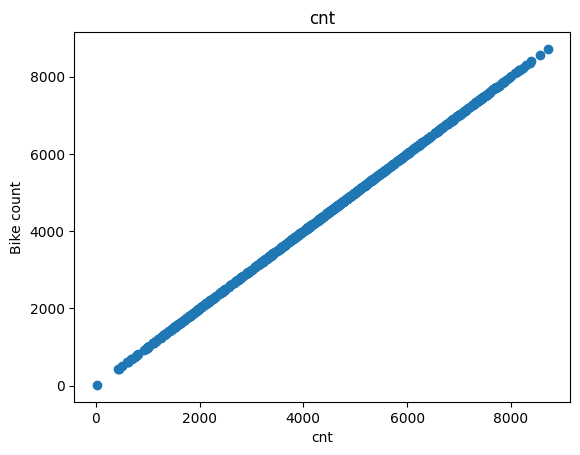

In [29]:
for parameter in daily_df.columns[1:]:
    plt.scatter(daily_df[parameter], daily_df['cnt'])
    plt.title(parameter)
    plt.ylabel('Bike count')
    plt.xlabel(parameter)
    plt.show()

In [30]:
#splitting the data into training and testing
train_data, test_data = np.split(daily_df, [int(len(daily_df) * 0.8)])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [31]:
X_train, y_train = train_data[[
    'temp',
    'hum',
    'windspeed',
    'season', 
    'holiday',
    'weathersit',
    'weekday',
    'workingday',
    'yr',
    'mnth'
    ]], train_data['cnt']

X_test, y_test = test_data[['temp',
    'hum',
    'windspeed',
    'season', 
    'holiday',
    'weathersit',
    'weekday',
    'workingday',
    'yr',
    'mnth']], test_data['cnt']

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
y_predict = model.predict(X_test)

In [33]:
model.coef_

array([ 4913.47826428,  -905.45308079, -2474.34511436,   289.22956589,
        -418.69888373,  -526.4691582 ,    45.5674295 ,    75.19972144,
        2038.58017284,    31.61535905])

In [34]:
model.intercept_

np.float64(1713.4316062087496)

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

full_data = pd.concat([train_data, test_data]).copy()
full_data['baseline_pred_7d'] = full_data['cnt'].shift(1).rolling(7).mean()

baseline_test = full_data.iloc[len(train_data):].copy()
baseline_test = baseline_test.dropna(subset=['baseline_pred_7d'])

baseline7_mae = mean_absolute_error(baseline_test['cnt'], baseline_test['baseline_pred_7d'])
print("Baseline (7-day rolling) MAE =", baseline7_mae)

Baseline (7-day rolling) MAE = 918.6307094266276


In [ ]:
mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)

print(f"Mean absolute error is: {mae}")
print(f"Mean squared error is: {mse}")
print(f"R^2: {r2}")

Mean absolute error is: 857.3545060292678
Mean squared error is: 1350671.4184021454
R^2: 0.615653310024943


This version of the model shows a drastic improvement from the previous version. Instead of just the weather like the previous model (```temp```, ```hum```, ```windspeed```) this model used previous inputs with the addition of (```season```,```holiday```,```weathersit```,```weekday```,```workingday```,```yr```,```mnth```).

MAE of this model beats the rolling average baseline (857 < 918), which tells us that on average our prediction is off by 857 and is not that big of a mistake, which is a huge improvement from the previous model (2004). 

The RMSE also drastically went down from 2200 to about 1100. So typical error scale is around a 1000 bikes.

Finally R^2 went from -38% which meant that the model was performing 38% worse than just a simple rolling average to +62%. 62% means that we have reduced the prediction error by 62% compared to just the rolling average. Or rather the model explains 62% of bike variability in bike demand.

I will try to make v3 of the model to improve it's accuracy.